In [1]:
# ============================================
# 01. Setup
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [2]:
book_dir = Path("/mnt/f/book")
languages = ["english", "french", "german"]

books = pd.DataFrame([
    {"language": lang, "book": path.stem, "path": path}
    for lang in languages
    for path in sorted((book_dir / lang).glob("*.txt"))
])

display(books)

,language,book,path
0,english,alice,/mnt/f/book/english/alice.txt
1,english,mobydick,/mnt/f/book/english/mobydick.txt
2,english,pride,/mnt/f/book/english/pride.txt
3,english,sherlock,/mnt/f/book/english/sherlock.txt
4,french,candide,/mnt/f/book/french/candide.txt
5,french,madame_bovary,/mnt/f/book/french/madame_bovary.txt
6,french,notre_dame,/mnt/f/book/french/notre_dame.txt
7,german,faust,/mnt/f/book/german/faust.txt
8,german,kafka_verwandlung,/mnt/f/book/german/kafka_verwandlung.txt
9,german,nietzsche_zarathustra,/mnt/f/book/german/nietzsche_zarathustra.txt


In [3]:
# ============================================
# 02. Sequence length
# ============================================

books["n_char"] = books["path"].apply(lambda p: len(p.read_text().strip()))

display(books[["language", "book", "n_char"]])
display(books.groupby("language")["n_char"].agg(["count", "mean", "min", "max"]).round(0))

,language,book,n_char
0,english,alice,163948
1,english,mobydick,1238277
2,english,pride,748165
3,english,sherlock,581599
4,french,candide,220804
5,french,madame_bovary,677684
6,french,notre_dame,1189469
7,german,faust,207095
8,german,kafka_verwandlung,141032
9,german,nietzsche_zarathustra,538591


,count,mean,min,max
language,,,,
english,4,682997.0,163948,1238277
french,3,695986.0,220804,1189469
german,3,295573.0,141032,538591


In [17]:
# ============================================
# 03. Load k-mer counts
# ============================================

kmer_dir = Path("../results/kmers")

kmer = {}
for k in range(1, 7):
    kmer[k] = pd.read_csv(kmer_dir / f"k{k}_book_counts.tsv", sep="\t")
    print(f"k={k}: {kmer[k].shape}")

display(kmer[2].head())

k=1: (572, 6)
k=2: (11822, 6)
k=3: (121306, 6)
k=4: (646290, 6)
k=5: (1799938, 6)
k=6: (3249516, 6)


,language,book,k,kmer,count,frequency
0,dutch,camera_obscura,2,PR,398,0.001094
1,dutch,camera_obscura,2,RO,2287,0.006286
2,dutch,camera_obscura,2,OD,709,0.001949
3,dutch,camera_obscura,2,DU,276,0.000759
4,dutch,camera_obscura,2,UC,486,0.001336


In [18]:
# ============================================
# 01. Balanced dataset
# ============================================

keep_books = {
    "english": ["alice", "pride", "sherlock"],
    "french": ["candide", "madame_bovary", "notre_dame"],
    "german": ["faust", "kafka_verwandlung", "nietzsche_zarathustra"],
}

data = {}
for k in [1, 2, 3]:
    df = kmer[k].query("language in @languages").copy()
    data[k] = df[df.apply(lambda x: x["book"] in keep_books[x["language"]], axis=1)]

for k, df in data.items():
    print(f"k={k}: {df['book'].nunique()} books | frequency sum/book:",
          df.groupby(["language", "book"])["frequency"].sum().round(3).unique())

k=1: 9 books | frequency sum/book: [1.]
k=2: 9 books | frequency sum/book: [1.]
k=3: 9 books | frequency sum/book: [1.]


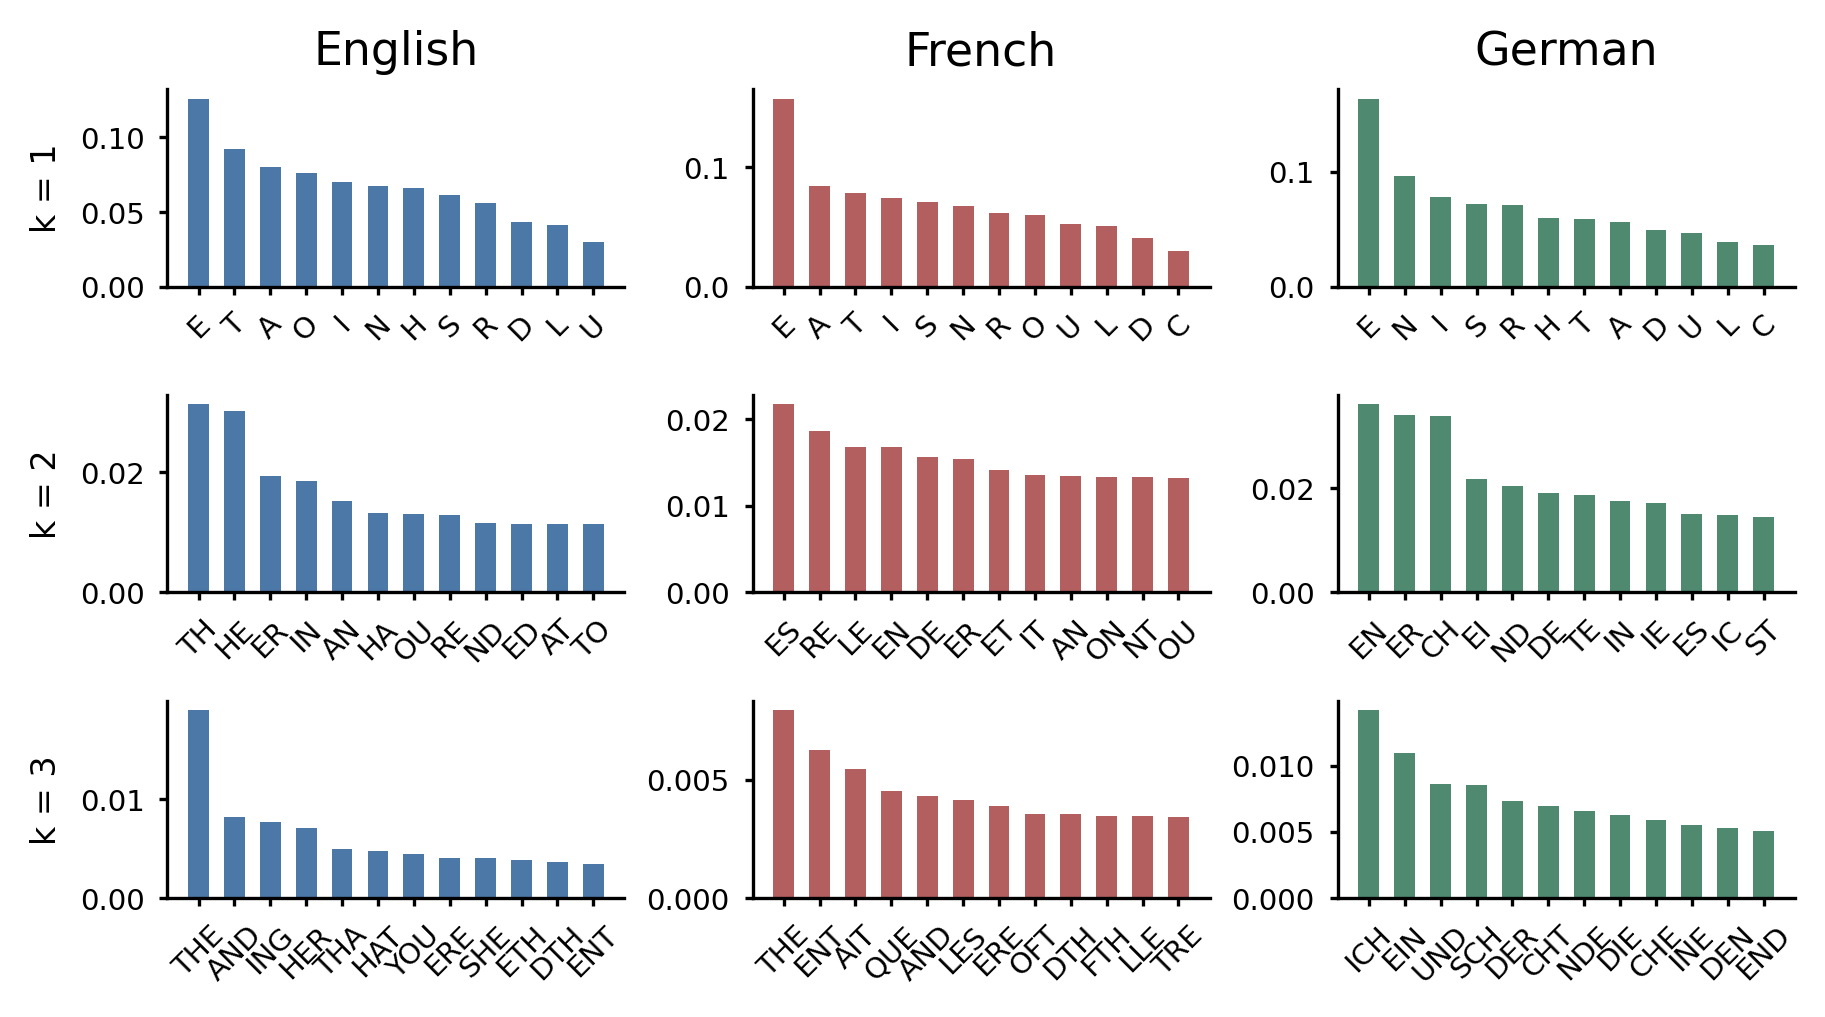

In [35]:
# ============================================
# 02. Mean k-mer profiles by language
# ============================================

colors = {"english": "#4C78A8", "french": "#B45F5F", "german": "#4F8A70"}

fig, axes = plt.subplots(3, 3, figsize=(7, 3.5), dpi=300)

for col, lang in enumerate(languages):
    for row, k in enumerate([1, 2, 3]):
        ax = axes[row, col]
        s = data[k].query("language == @lang").groupby("kmer")["frequency"].mean().nlargest(12)

        ax.bar(s.index, s.values, width=0.58, color=colors[lang])
        ax.tick_params(axis="x", rotation=45, labelsize=7, length=2)
        ax.tick_params(axis="y", labelsize=7, length=2)
        ax.spines[["top", "right"]].set_visible(False)

        if row == 0: ax.set_title(lang.capitalize(), fontsize=11)
        if col == 0: ax.set_ylabel(f"k = {k}", fontsize=8)

fig.subplots_adjust(wspace=0.28, hspace=0.55)
plt.show()

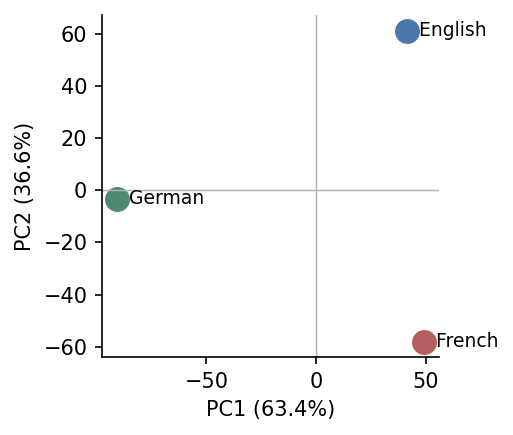

In [45]:
# ============================================
# 03. PCA of combined k=1,2,3 profiles
# ============================================

blocks = []

for k in [1, 2, 3]:
    d = data[k].groupby(["language", "kmer"])["frequency"].mean().unstack(fill_value=0)
    d = d.sub(d.mean()).div(d.std().replace(0, 1))
    d.columns = [f"k{k}_{x}" for x in d.columns]
    blocks.append(d)

X_lang = pd.concat(blocks, axis=1).loc[languages]

pca = PCA(n_components=2)
Z = pca.fit_transform(X_lang)

pca_df = pd.DataFrame(Z, index=X_lang.index, columns=["PC1", "PC2"])

fig, ax = plt.subplots(figsize=(3.5, 3), dpi=150)

for lang in languages:
    ax.scatter(pca_df.loc[lang, "PC1"], pca_df.loc[lang, "PC2"],
               s=120, color=colors[lang], label=lang.capitalize())
    ax.text(pca_df.loc[lang, "PC1"], pca_df.loc[lang, "PC2"],
            f"  {lang.capitalize()}", va="center", fontsize=9)

ax.axhline(0, lw=0.7, color="0.7"); ax.axvline(0, lw=0.7, color="0.7")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.spines[["top", "right"]].set_visible(False)
# ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [46]:
# ============================================
# 04. Features driving PCA separation
# ============================================

loadings = pd.DataFrame({
    "feature": X_lang.columns,
    "PC1": pca.components_[0],
    "PC2": pca.components_[1],
})

loadings["contribution"] = np.sqrt(loadings["PC1"]**2 + loadings["PC2"]**2)
loadings["k"] = loadings["feature"].str.extract(r"k(\d)").astype(int)
loadings["kmer"] = loadings["feature"].str.replace(r"k\d_", "", regex=True)

top = loadings.nlargest(20, "contribution")

display(top[["k", "kmer", "PC1", "PC2", "contribution"]].round(3))

,k,kmer,PC1,PC2,contribution
8462,3,UTT,0.0,0.017,0.017
1197,3,BAM,0.0,-0.017,0.017
8603,3,VIB,0.0,-0.017,0.017
1278,3,BIG,-0.0,-0.017,0.017
152,2,EW,0.0,0.017,0.017
1236,3,BEG,0.0,0.017,0.017
190,2,GJ,-0.0,0.017,0.017
8150,3,UEG,-0.0,-0.017,0.017
9549,3,ZEJ,0.0,-0.017,0.017
7285,3,SAB,-0.0,-0.017,0.017


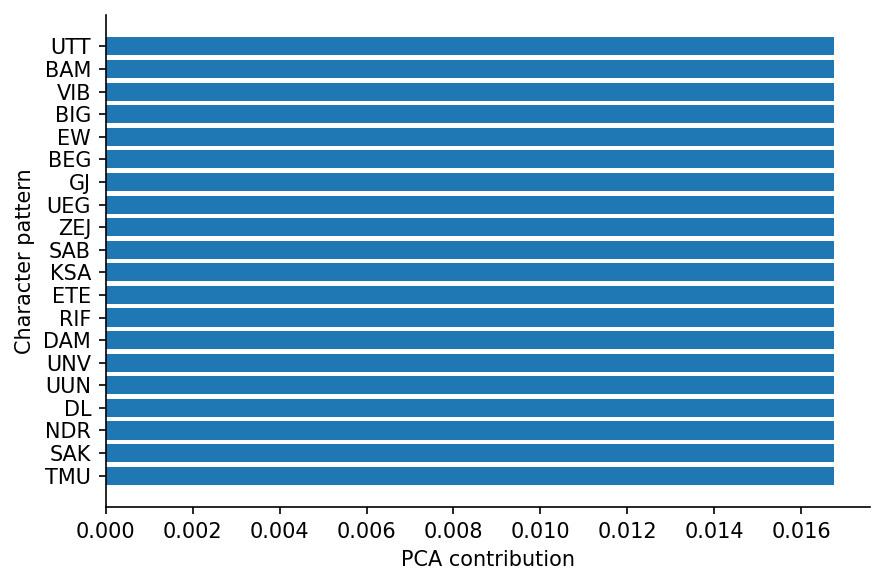

In [47]:
# Top character patterns separating the languages

top = top.sort_values("contribution")

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.barh(top["kmer"], top["contribution"])

ax.set_xlabel("PCA contribution")
ax.set_ylabel("Character pattern")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [48]:
# ============================================
# 04. Language-characteristic k-mers
# ============================================

characteristic = []

for k in [1, 2, 3]:
    m = data[k].groupby(["language", "kmer"])["frequency"].mean().unstack(fill_value=0)

    for lang in languages:
        score = m.loc[lang] / (m.drop(lang).mean() + 1e-12)
        top = score.nlargest(10)

        characteristic.append(pd.DataFrame({
            "language": lang, "k": k, "kmer": top.index,
            "enrichment": top.values
        }))

characteristic = pd.concat(characteristic, ignore_index=True)

display(characteristic)

,language,k,kmer,enrichment
0,english,1,Y,5.643015e+00
1,english,1,W,1.896541e+00
2,english,1,O,1.798760e+00
3,english,1,H,1.485621e+00
4,english,1,F,1.364933e+00
...,...,...,...,...
85,german,3,ZUS,7.613660e+08
86,german,3,UFD,7.144620e+08
87,german,3,TZU,7.008084e+08
88,german,3,ZUM,6.869101e+08


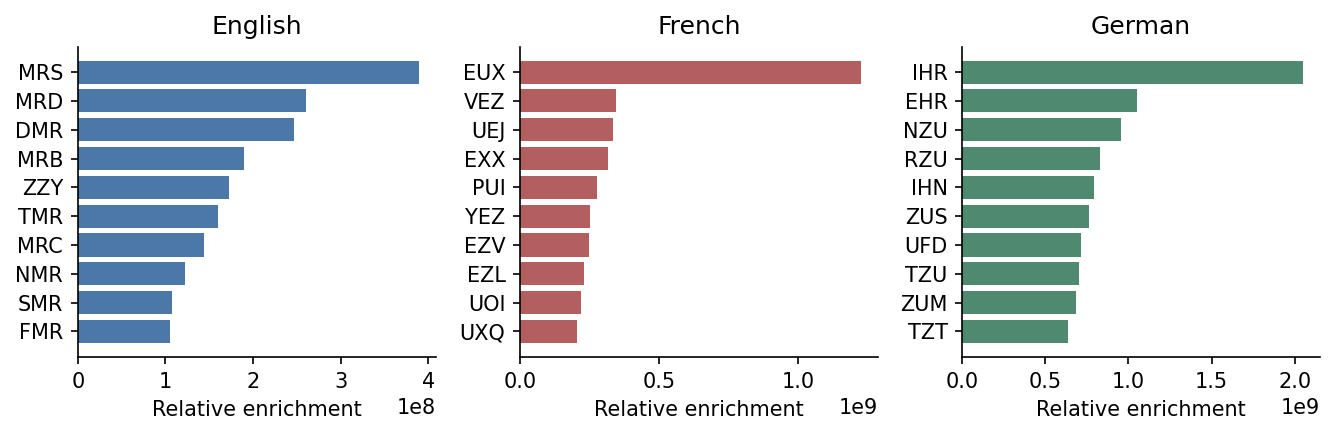

In [51]:
# ============================================
# 05. Strongest patterns for each language
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(9, 3), dpi=150)

for ax, lang in zip(axes, languages):
    d = characteristic.query("language == @lang").nlargest(10, "enrichment").sort_values("enrichment")

    ax.barh(d["kmer"], d["enrichment"], color=colors[lang])
    ax.set_title(lang.capitalize())
    ax.set_xlabel("Relative enrichment")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [55]:
# ============================================
# 03. Language-specific k-mers
# ============================================

specificity = []

for k in [1, 2, 3]:
    m = data[k].groupby(["language", "kmer"])["frequency"].mean().unstack(fill_value=0)

    for lang in languages:
        score = m.loc[lang] - m.drop(lang).mean()
        top = score.nlargest(10)

        specificity.append(pd.DataFrame({
            "language": lang, "k": k,
            "kmer": top.index, "score": top.values
        }))

specificity = pd.concat(specificity, ignore_index=True)

display(specificity)

,language,k,kmer,score
0,english,1,O,0.033691
1,english,1,T,0.023639
2,english,1,H,0.021677
3,english,1,Y,0.018182
4,english,1,W,0.011574
...,...,...,...,...
85,german,3,DER,0.006409
86,german,3,DIE,0.006012
87,german,3,NDE,0.005047
88,german,3,CHE,0.004744


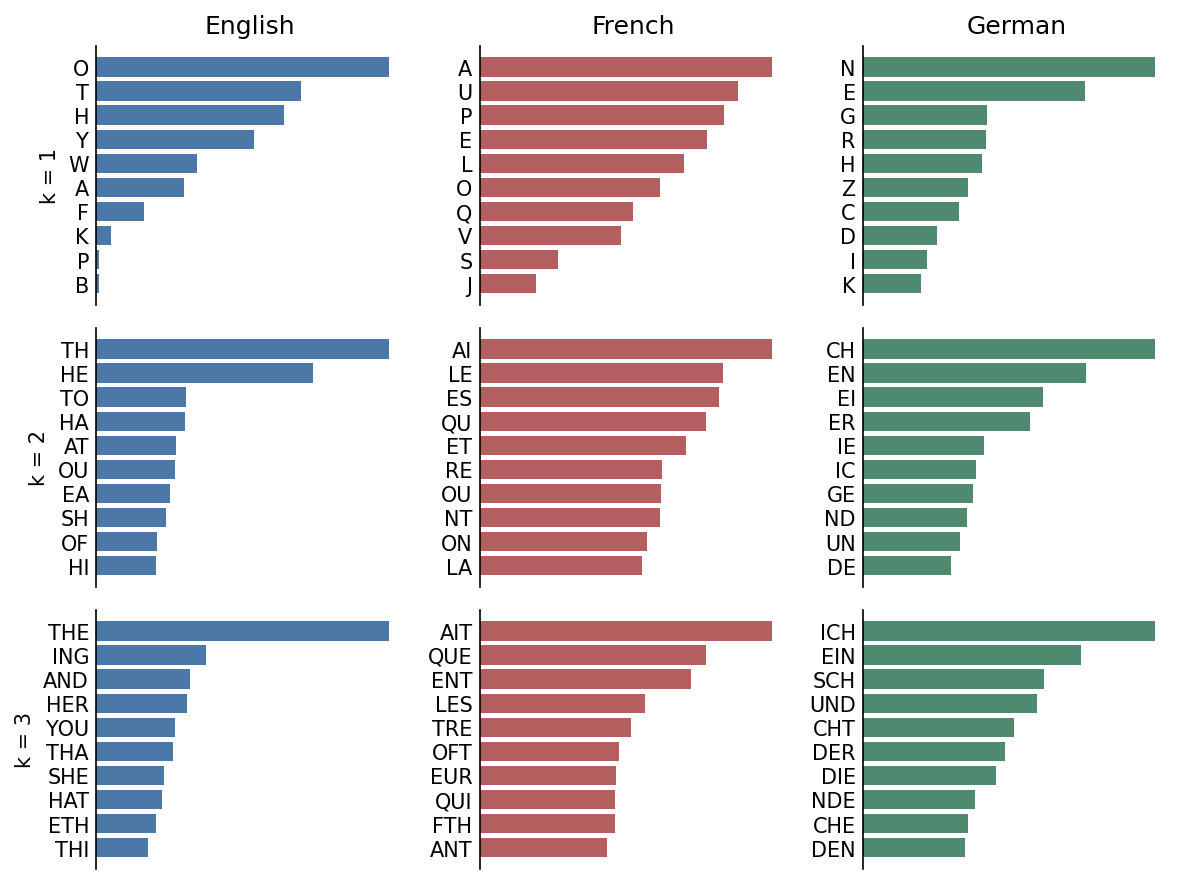

In [56]:
# ============================================
# 04. Characteristic k-mers
# ============================================

fig, axes = plt.subplots(3, 3, figsize=(8, 6), dpi=150)

for col, lang in enumerate(languages):
    for row, k in enumerate([1, 2, 3]):
        ax = axes[row, col]
        d = specificity.query("language == @lang and k == @k").sort_values("score")

        ax.barh(d["kmer"], d["score"], color=colors[lang])
        ax.set_xticks([])
        ax.tick_params(axis="y", length=0)
        ax.spines[["top", "right", "bottom"]].set_visible(False)

        if row == 0:
            ax.set_title(lang.capitalize(), fontsize=12)
        if col == 0:
            ax.set_ylabel(f"k = {k}")

plt.tight_layout()
plt.show()

In [57]:
# ============================================
# 05. Separation by k-mer level
# ============================================

from itertools import combinations
from scipy.spatial.distance import cosine

rows = []

for k in [1, 2, 3]:
    m = data[k].groupby(["language", "kmer"])["frequency"].mean().unstack(fill_value=0)

    for a, b in combinations(languages, 2):
        rows.append([k, a, b, cosine(m.loc[a], m.loc[b])])

separation = pd.DataFrame(
    rows, columns=["k", "language_1", "language_2", "distance"]
)

display(separation)
display(separation.groupby("k")["distance"].mean().rename("Mean distance"))

,k,language_1,language_2,distance
0,1,english,french,0.031131
1,1,english,german,0.058747
2,1,french,german,0.039699
3,2,english,french,0.156860
4,2,english,german,0.349105
5,2,french,german,0.282624
6,3,english,french,0.296734
7,3,english,german,0.672169
8,3,french,german,0.599450


k
1    0.043192
2    0.262863
3    0.522784
Name: Mean distance, dtype: float64

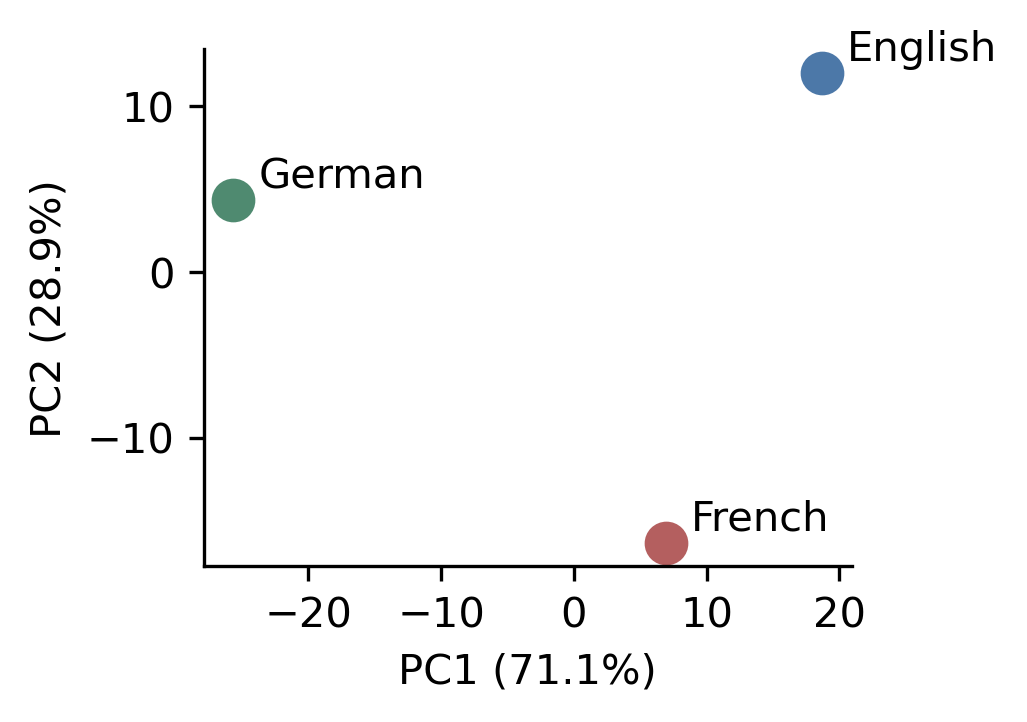

In [61]:
# ============================================
# 06. PCA: language sequence profiles
# ============================================

X = []

for k in [1, 2, 3]:
    m = data[k].groupby(["language", "kmer"])["frequency"].mean().unstack(fill_value=0)
    m.columns = [f"k{k}_{x}" for x in m.columns]
    X.append(m)

X = pd.concat(X, axis=1).fillna(0).loc[languages]

pca = PCA(n_components=2)
Z = pca.fit_transform(StandardScaler().fit_transform(X.T).T)

pca_df = pd.DataFrame(Z, index=X.index, columns=["PC1", "PC2"])

fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=300)

for lang in languages:
    ax.scatter(*pca_df.loc[lang], s=90, color=colors[lang])
    ax.annotate(lang.capitalize(), pca_df.loc[lang], xytext=(6, 3),
                textcoords="offset points")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [62]:
# ============================================
# 05. Information by k-mer level
# ============================================

info = (
    specificity.assign(score_pos=lambda x: x["score"].clip(lower=0))
    .groupby(["language", "k"])["score_pos"].sum()
    .unstack(fill_value=0)
)

info_pct = info.div(info.sum(axis=1), axis=0) * 100
display(info_pct.round(1))

k,1,2,3
language,,,
english,47.4,33.9,18.6
french,48.0,36.7,15.3
german,36.5,42.6,20.9
